In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

# Load FINAL dataset
df = pd.read_csv(r"D:\capstone project dataset\11.01 final\CRA_DATASET_FIXED.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (20286, 32)


,State,District,Year,Season,Yield_kg_per_ha,Soil_Organic_Carbon,Soil_pH,N,P,K,...,Aerosol_Optical_Depth,CO2_Concentration,Irrigation_Coverage,Groundwater_Depth,Irrigation_Source,Seed_Variety,Temp_Anomaly,Climate_Stress_Index,Resilience_Class,Nutrient_Intensity
0,Chhattisgarh,Durg,2000,Kharif,624.89,0.5584,7.24,15.62225,7.49868,13.74758,...,2.515496,445.512719,28.420999,34.783504,Canal,Local,2.306358,0.697486,Low,0.013503
1,Chhattisgarh,Durg,2000,Kharif,792.52,0.5246,6.84,21.39804,9.51024,13.47284,...,2.653901,440.650942,25.993150,26.626331,Canal,Local,-0.693642,-0.726063,Medium,0.016355
2,Chhattisgarh,Durg,2000,Kharif,506.84,0.5162,6.67,9.12312,5.06840,9.12312,...,1.377346,429.083769,32.800820,28.163458,Canal,Local,-2.693642,-0.578101,Medium,0.008640
3,Chhattisgarh,Durg,2001,Kharif,1294.13,0.5445,6.83,32.35325,15.52956,28.47086,...,3.000000,436.390189,35.118709,26.606628,Canal,Local,2.306358,0.092743,Medium,0.027773
4,Chhattisgarh,Durg,2001,Kharif,672.21,0.5506,7.75,18.14967,8.06652,11.42757,...,1.497527,414.469057,26.231926,30.003135,Canal,Hybrid,-0.693642,-0.726063,Medium,0.013888


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20286 entries, 0 to 20285
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    20286 non-null  object 
 1   District                 20286 non-null  object 
 2   Year                     20286 non-null  int64  
 3   Season                   20286 non-null  object 
 4   Yield_kg_per_ha          20286 non-null  float64
 5   Soil_Organic_Carbon      20286 non-null  float64
 6   Soil_pH                  20286 non-null  float64
 7   N                        20286 non-null  float64
 8   P                        20286 non-null  float64
 9   K                        20286 non-null  float64
 10  Water_Holding_Capacity   20286 non-null  float64
 11  Electrical_Conductivity  20286 non-null  float64
 12  Avg_Temperature          20286 non-null  float64
 13  Heatwave_Days            20286 non-null  int64  
 14  Dry_Spell_Count       

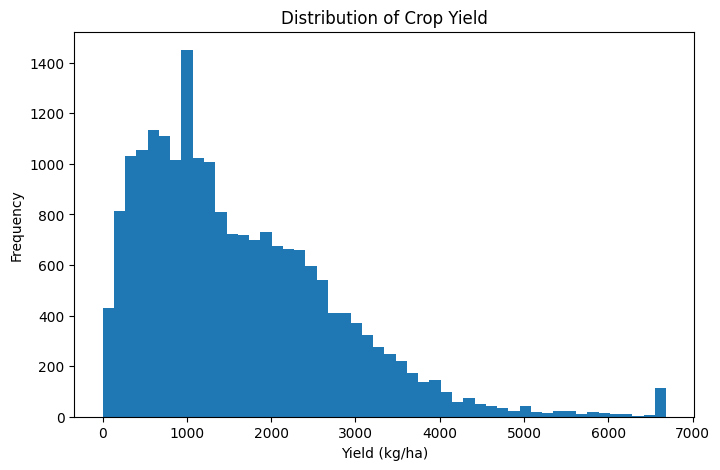

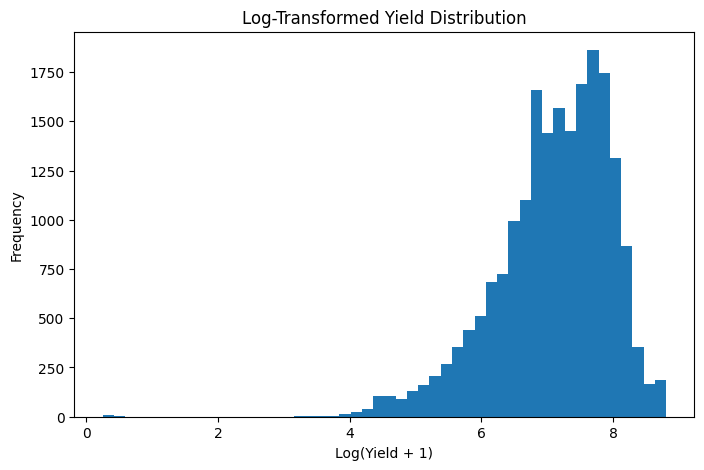

In [3]:
plt.hist(df["Yield_kg_per_ha"], bins=50)
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Frequency")
plt.title("Distribution of Crop Yield")
plt.show()

plt.hist(np.log1p(df["Yield_kg_per_ha"]), bins=50)
plt.xlabel("Log(Yield + 1)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Yield Distribution")
plt.show()


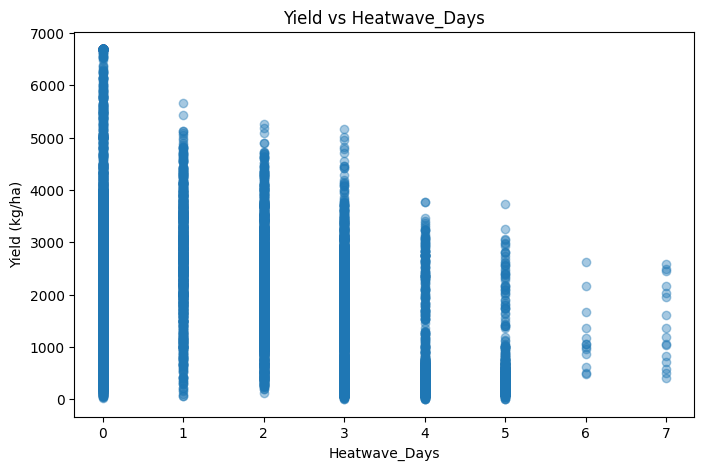

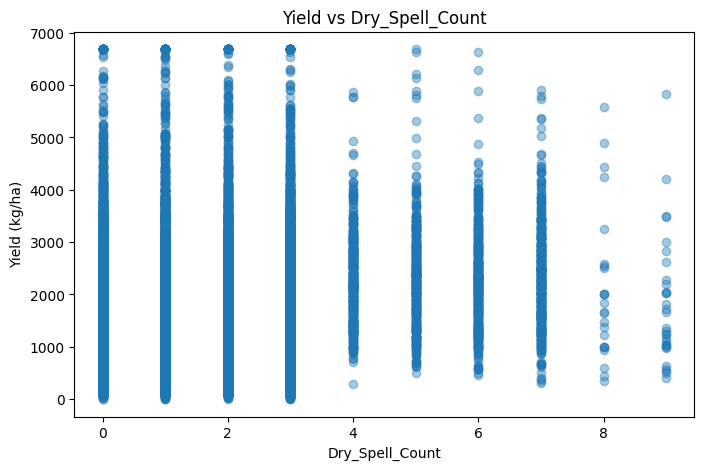

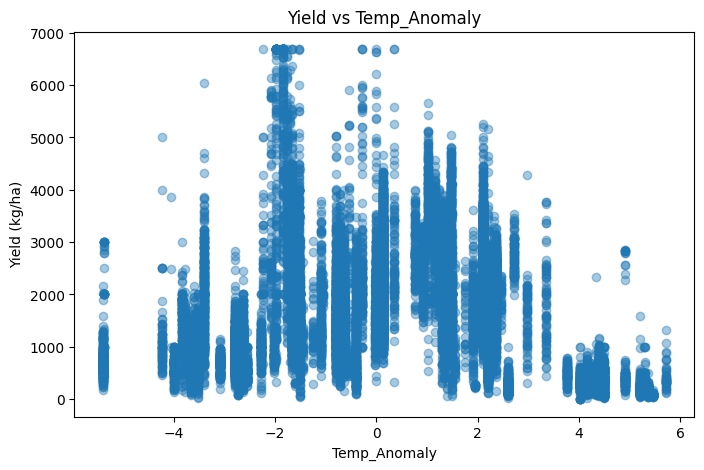

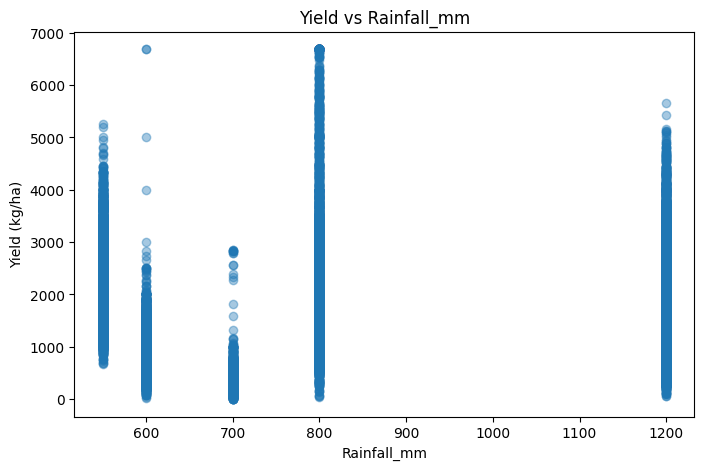

In [4]:
stress_features = [
    "Heatwave_Days",
    "Dry_Spell_Count",
    "Temp_Anomaly",
    "Rainfall_mm"
]

for col in stress_features:
    plt.scatter(df[col], df["Yield_kg_per_ha"], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("Yield (kg/ha)")
    plt.title(f"Yield vs {col}")
    plt.show()


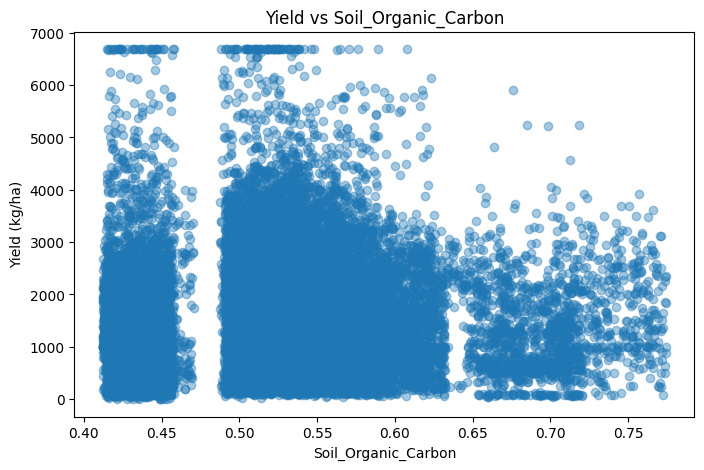

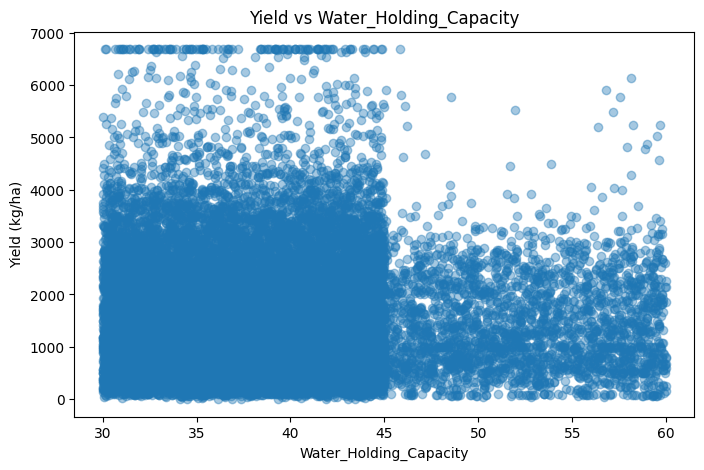

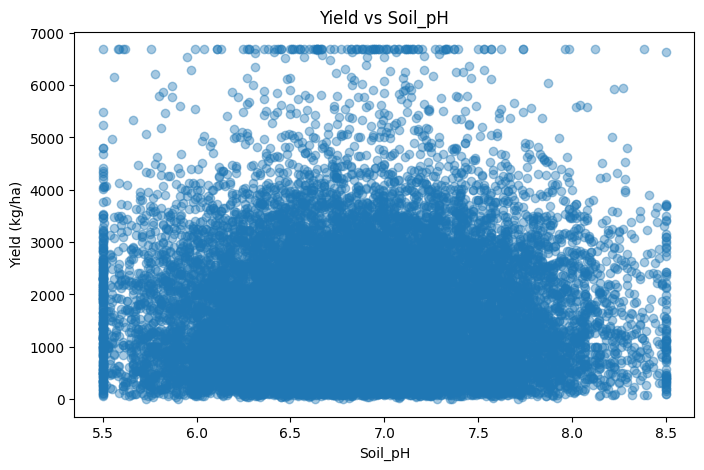

In [5]:
soil_features = [
    "Soil_Organic_Carbon",
    "Water_Holding_Capacity",
    "Soil_pH"
]

for col in soil_features:
    plt.scatter(df[col], df["Yield_kg_per_ha"], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("Yield (kg/ha)")
    plt.title(f"Yield vs {col}")
    plt.show()


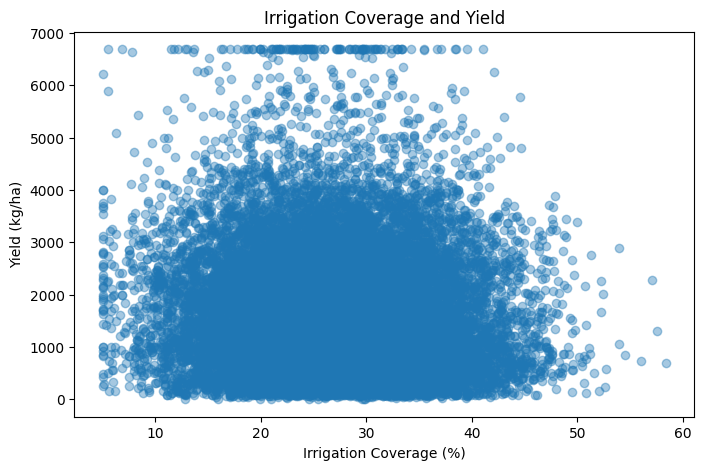

C:\Users\tanma\AppData\Local\Temp\ipykernel_24560\1621392482.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sources)


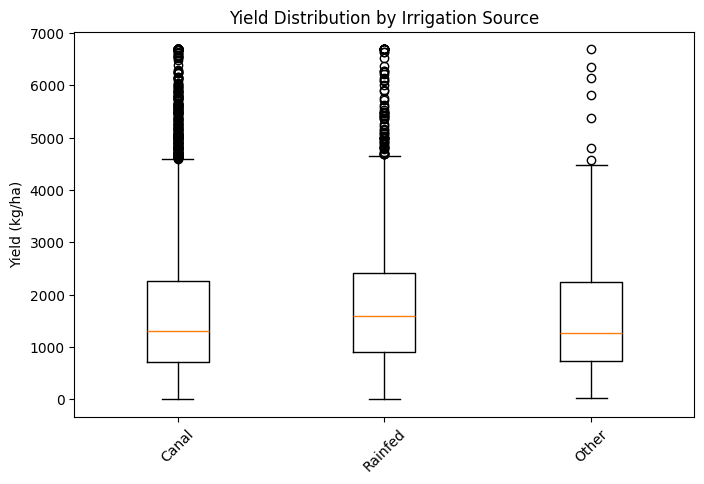

In [6]:
# Yield vs irrigation coverage
plt.scatter(df["Irrigation_Coverage"], df["Yield_kg_per_ha"], alpha=0.4)
plt.xlabel("Irrigation Coverage (%)")
plt.ylabel("Yield (kg/ha)")
plt.title("Irrigation Coverage and Yield")
plt.show()

# Yield by irrigation source
sources = df["Irrigation_Source"].unique()
data = [df[df["Irrigation_Source"] == s]["Yield_kg_per_ha"] for s in sources]

plt.boxplot(data, labels=sources)
plt.xticks(rotation=45)
plt.ylabel("Yield (kg/ha)")
plt.title("Yield Distribution by Irrigation Source")
plt.show()


C:\Users\tanma\AppData\Local\Temp\ipykernel_24560\926678849.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(season_data, labels=seasons)


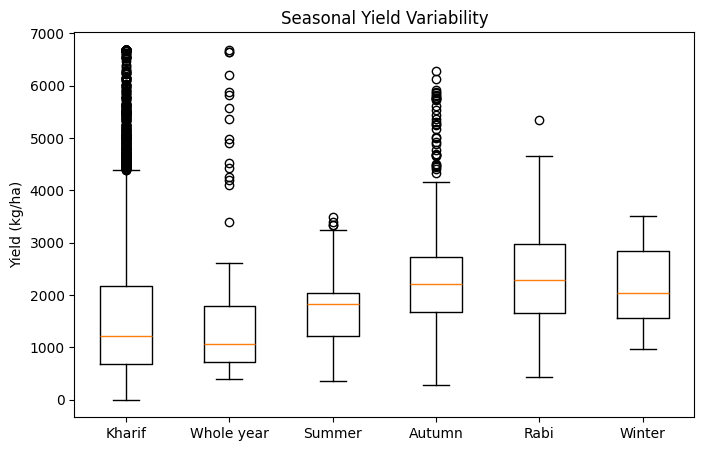

C:\Users\tanma\AppData\Local\Temp\ipykernel_24560\926678849.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(state_data, labels=top_states)


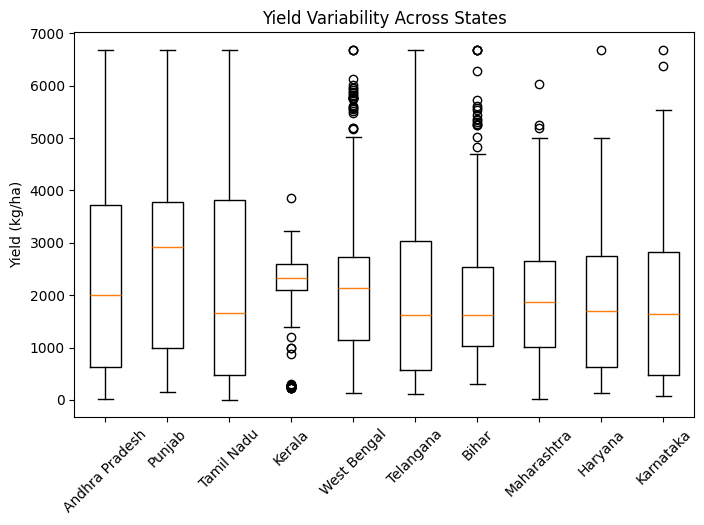

In [7]:
# Yield by season
seasons = df["Season"].unique()
season_data = [df[df["Season"] == s]["Yield_kg_per_ha"] for s in seasons]

plt.boxplot(season_data, labels=seasons)
plt.ylabel("Yield (kg/ha)")
plt.title("Seasonal Yield Variability")
plt.show()

# State-wise yield (top 10)
top_states = df.groupby("State")["Yield_kg_per_ha"].mean().sort_values(ascending=False).head(10).index
state_data = [df[df["State"] == s]["Yield_kg_per_ha"] for s in top_states]

plt.boxplot(state_data, labels=top_states)
plt.xticks(rotation=45)
plt.ylabel("Yield (kg/ha)")
plt.title("Yield Variability Across States")
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

stress_cols = ["Heatwave_Days", "Dry_Spell_Count", "Temp_Anomaly"]

scaler = StandardScaler()
df["Climate_Stress_Index"] = scaler.fit_transform(df[stress_cols]).mean(axis=1)

plt.scatter(df["Climate_Stress_Index"], df["Yield_kg_per_ha"], alpha=0.4)
plt.xlabel("Climate Stress Index")
plt.ylabel("Yield (kg/ha)")
plt.title("Yield Performance Under Climate Stress")
plt.show()
